# Notebook 05 – Goal 5: Cross-Notebook Synthesis

**Authors:** Ivo Rambaldi & Tommaso Petrelli
**Course:** Ethics for Artificial Intelligence, University of Bologna, a.y. 2025–2026

---

## Goal 5 — Bringing G3/G4 together

G3 and G4 each answer part of the question; this notebook combines their saved outputs into one
comparison along the three axes the project cares about:

1. **Training data**: real vs. each synthetic generator (CTGAN, TVAE, GaussianCopula, SMOTE)
2. **Task**: excellence (`target_high_perf`) vs. underperformance (`target_low_perf`)
3. **Mitigation**: none (G4's grid) vs. Equalized Odds / Prejudice Remover (G3's mitigation section)

It does **not** retrain anything — it only reads the CSVs G3/G3_LowPerf/G4/G4_LowPerf already wrote to
`results/mitigation/{high_perf,low_perf}/` and `results/no_mitigation/{high_perf,low_perf}/`
(each notebook now writes to its own dedicated sub-directory, both for CSVs and figures, so none of
the four ever overwrite each other's output — see note.txt for when/why this changed), so re-run
those four notebooks first if you want this one to reflect fresh numbers.

> **Data provenance note (fill in / verify before citing numbers):** check the mtimes of
> `results/no_mitigation/*/metrics_matrix.csv` (G4) and `results/mitigation/*/goal3_mitigation_results.csv`
> (G3) against G2's synthetic CSVs before trusting a comparison here -- and check that G4/G4_LowPerf were
> run with a **restarted** kernel, not just "run all" in an already-warm one (a stale-import issue caught
> the last time this was checked: G4's saved output was missing the `degenerate_predictions` column and
> had zero odds_ratio values suppressed, both signs it was still running pre-fix code despite a fresh
> file timestamp).

> **Note.** This notebook's `> 📝 Result` cells give the numeric detail; the final project report gives
> the narrative version aimed at a reader who hasn't run the notebooks themselves.


## 1 · Setup

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure the project root is on sys.path so 'src' imports resolve correctly
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
warnings.filterwarnings("ignore")

from src.utils import get_logger, load_config, check_prerequisites
from src.data.persistence import ensure_dir, save_csv

logger = get_logger("notebook_05")
check_prerequisites()

cfg = load_config(PROJECT_ROOT / 'config' / 'config.yaml')

G5_RESULTS_DIR = cfg["paths"]["results_dir"] / "g5"
G5_FIGURES_DIR = cfg["paths"]["figures_dir"] / "g5"
ensure_dir(G5_RESULTS_DIR)
ensure_dir(G5_FIGURES_DIR)

# G3/G3_LowPerf (mitigation) and G4/G4_LowPerf (no mitigation) each write to their
# own dedicated sub-directory -- see their setup cells.
MITIGATION_DIRS = {
    "high_perf": cfg["paths"]["results_dir"] / "mitigation" / "high_perf",
    "low_perf":  cfg["paths"]["results_dir"] / "mitigation" / "low_perf",
}
NO_MITIGATION_DIRS = {
    "high_perf": cfg["paths"]["results_dir"] / "no_mitigation" / "high_perf",
    "low_perf":  cfg["paths"]["results_dir"] / "no_mitigation" / "low_perf",
}

TASKS = ["high_perf", "low_perf"]
MITIGATION_ORDER = ["none", "equalized_odds", "prejudice_remover"]

sns.set_theme(style="whitegrid")
print("G5 setup ready.")
print(f"Results dir : {G5_RESULTS_DIR}")
print(f"Figures dir : {G5_FIGURES_DIR}")


Prerequisites check (requirements.txt): 16 OK, 0 missing, 0 version-mismatched.
G5 setup ready.
Results dir : C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5
Figures dir : C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5


## 2 · Load results

### 2.1 Unmitigated grid (G4.ipynb / G4_LowPerf.ipynb)


In [2]:
def normalize_generator(name: str) -> str:
    """Collapse the low-perf-specific SMOTE variant onto the shared 'smote' label
    so the two tasks' generators line up in one comparison (they're the same
    technique, just re-run with a different conditioning target)."""
    return "smote" if name == "smote_low_perf" else name


def load_unmitigated(task: str, path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["task"] = task
    df["mitigation"] = "none"
    df["generator"] = df["method"].map(normalize_generator)
    df["source_type"] = np.where(df["method"] == cfg["experiments"]["baseline_label"], "real", "synthetic")
    return df


unmitigated_high = load_unmitigated("high_perf", NO_MITIGATION_DIRS["high_perf"] / "metrics_matrix.csv")
unmitigated_low  = load_unmitigated("low_perf",  NO_MITIGATION_DIRS["low_perf"] / "metrics_matrix.csv")

unmitigated_df = pd.concat([unmitigated_high, unmitigated_low], ignore_index=True)
print(f"Unmitigated grid: {unmitigated_df.shape}")
unmitigated_df[["task", "generator", "classifier", "balanced_accuracy", "mean_dpd", "mmd"]].head(10)


Unmitigated grid: (30, 70)


,task,generator,classifier,balanced_accuracy,mean_dpd,mmd
0,high_perf,real,logistic_regression,0.626449,0.352740,0.000000
1,high_perf,ctgan,logistic_regression,0.565316,0.279654,0.003424
2,high_perf,tvae,logistic_regression,0.604171,0.381024,0.024449
3,high_perf,gaussian_copula,logistic_regression,0.432486,0.270140,0.002459
4,high_perf,smote,logistic_regression,0.609108,0.270669,0.001972
5,high_perf,real,xgboost,0.654336,0.354172,0.000000
6,high_perf,ctgan,xgboost,0.538848,0.165671,0.003424
7,high_perf,tvae,xgboost,0.613691,0.378560,0.024449
8,high_perf,gaussian_copula,xgboost,0.448182,0.158779,0.002459
9,high_perf,smote,xgboost,0.529342,0.097308,0.001972


### 2.2 Mitigated grid (G3.ipynb / G3_LowPerf.ipynb)


In [3]:
def load_mitigated(task: str, path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    keep_cols = [
        "technique", "method", "classifier", "balanced_accuracy", "f1_macro", "roc_auc",
        "mean_dpd", "mean_eod", "mean_di", "mean_odds_ratio", "degenerate_predictions",
    ]
    keep_cols = [c for c in keep_cols if c in df.columns]
    grouped = (
        df[keep_cols]
        .groupby(["technique", "method", "classifier"], as_index=False)
        .mean(numeric_only=True)
    )
    grouped["task"] = task
    grouped["mitigation"] = grouped.pop("technique")
    grouped["generator"] = grouped["method"].map(normalize_generator)
    grouped["source_type"] = np.where(grouped["method"] == cfg["experiments"]["baseline_label"], "real", "synthetic")
    return grouped


mitigated_high = load_mitigated("high_perf", MITIGATION_DIRS["high_perf"] / "goal3_mitigation_results.csv")
mitigated_low  = load_mitigated("low_perf",  MITIGATION_DIRS["low_perf"] / "goal3_mitigation_results.csv")

mitigated_df = pd.concat([mitigated_high, mitigated_low], ignore_index=True)
print(f"Mitigated grid: {mitigated_df.shape}")
mitigated_df[["task", "mitigation", "generator", "classifier", "balanced_accuracy", "mean_dpd"]].head(10)


Mitigated grid: (40, 14)


,task,mitigation,generator,classifier,balanced_accuracy,mean_dpd
0,high_perf,equalized_odds,ctgan,logistic_regression,0.543924,0.134736
1,high_perf,equalized_odds,ctgan,mlp,0.524100,0.107885
2,high_perf,equalized_odds,ctgan,xgboost,0.526030,0.107820
3,high_perf,equalized_odds,gaussian_copula,logistic_regression,0.437947,0.239072
4,high_perf,equalized_odds,gaussian_copula,mlp,0.471968,0.160869
5,high_perf,equalized_odds,gaussian_copula,xgboost,0.448537,0.167497
6,high_perf,equalized_odds,real,logistic_regression,0.607931,0.252707
7,high_perf,equalized_odds,real,mlp,0.625320,0.242772
8,high_perf,equalized_odds,real,xgboost,0.642682,0.274873
9,high_perf,equalized_odds,smote,logistic_regression,0.601247,0.230754


### 2.3 Combine into one tidy frame



In [4]:
mmd_lookup = (
    unmitigated_df[unmitigated_df["source_type"] == "synthetic"]
    .groupby(["task", "generator"])["mmd"].first()
)

combined_cols = [
    "task", "mitigation", "generator", "source_type", "classifier",
    "balanced_accuracy", "f1_macro", "roc_auc",
    "mean_dpd", "mean_eod", "mean_di", "mean_odds_ratio", "degenerate_predictions",
]
combined_cols = [c for c in combined_cols if c in unmitigated_df.columns or c in mitigated_df.columns]

combined_df = pd.concat(
    [unmitigated_df[[c for c in combined_cols if c in unmitigated_df.columns]],
     mitigated_df[[c for c in combined_cols if c in mitigated_df.columns]]],
    ignore_index=True,
)
combined_df["mitigation"] = pd.Categorical(combined_df["mitigation"], categories=MITIGATION_ORDER, ordered=True)
combined_df["mmd"] = combined_df.set_index(["task", "generator"]).index.map(mmd_lookup.to_dict())
combined_df.loc[combined_df["source_type"] == "real", "mmd"] = 0.0

save_csv(combined_df, G5_RESULTS_DIR / "combined_results.csv")
logger.info(f"Combined results saved -> {G5_RESULTS_DIR / 'combined_results.csv'}")
print(f"Combined frame: {combined_df.shape}")
combined_df.sample(min(10, len(combined_df)), random_state=cfg["seed"])


2026-07-25 05:24:03 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5\combined_results.csv


2026-07-25 05:24:03 | INFO     | notebook_05 | Combined results saved -> C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5\combined_results.csv


Combined frame: (70, 14)


,task,mitigation,generator,source_type,classifier,balanced_accuracy,f1_macro,roc_auc,mean_dpd,mean_eod,mean_di,mean_odds_ratio,degenerate_predictions,mmd
22,low_perf,none,tvae,synthetic,xgboost,0.615470,0.580414,0.657145,0.342496,0.383706,0.370121,4.177446,0.0,0.024449
0,high_perf,none,real,real,logistic_regression,0.626449,0.593596,0.677418,0.352740,0.356601,0.480914,0.868536,0.0,0.000000
49,high_perf,prejudice_remover,tvae,synthetic,prejudice_remover,0.564316,0.566579,0.651135,0.239535,0.310341,0.246293,1.334194,0.0,0.024449
4,high_perf,none,smote,synthetic,logistic_regression,0.609108,0.562140,0.664906,0.270669,0.265300,0.600356,0.882637,0.0,0.001972
54,low_perf,equalized_odds,gaussian_copula,synthetic,mlp,0.524012,0.499071,0.524012,0.116528,0.122102,0.762365,1.113814,0.0,0.002459
18,low_perf,none,gaussian_copula,synthetic,logistic_regression,0.602343,0.556472,0.633004,0.325767,0.338052,0.448424,2.301649,0.0,0.002459
10,high_perf,none,real,real,mlp,0.566257,0.563753,0.697005,0.097258,0.142752,0.348264,0.917745,0.0,0.000000
33,high_perf,equalized_odds,gaussian_copula,synthetic,logistic_regression,0.437947,0.418614,0.437947,0.239072,0.245304,0.576287,1.637161,0.0,0.002459
45,high_perf,prejudice_remover,ctgan,synthetic,prejudice_remover,0.500000,0.431164,0.567663,0.001267,0.001685,0.298174,0.455452,0.083333,0.003424
12,high_perf,none,tvae,synthetic,mlp,0.587402,0.592353,0.655790,0.307759,0.356689,0.307787,1.279606,0.0,0.024449


## 3 · Utility: synthetic vs. real, by task and mitigation status

In [5]:
utility_summary = (
    combined_df
    .groupby(["task", "mitigation", "source_type", "generator"], observed=True)["balanced_accuracy"]
    .mean()
    .reset_index()
    .sort_values(["task", "mitigation", "source_type"])
)
save_csv(utility_summary, G5_RESULTS_DIR / "utility_summary_by_task_mitigation.csv")
print("Mean balanced accuracy by task x mitigation x generator (averaged across classifiers):\n")
print(utility_summary.round(4).to_string(index=False))


2026-07-25 05:24:03 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5\utility_summary_by_task_mitigation.csv


Mean balanced accuracy by task x mitigation x generator (averaged across classifiers):

     task        mitigation source_type       generator  balanced_accuracy
high_perf              none        real            real             0.6157
high_perf              none   synthetic           ctgan             0.5347
high_perf              none   synthetic gaussian_copula             0.4602
high_perf              none   synthetic           smote             0.5671
high_perf              none   synthetic            tvae             0.6018
high_perf    equalized_odds        real            real             0.6253
high_perf    equalized_odds   synthetic           ctgan             0.5314
high_perf    equalized_odds   synthetic gaussian_copula             0.4528
high_perf    equalized_odds   synthetic           smote             0.5678
high_perf    equalized_odds   synthetic            tvae             0.6000
high_perf prejudice_remover        real            real             0.5294
high_perf pr

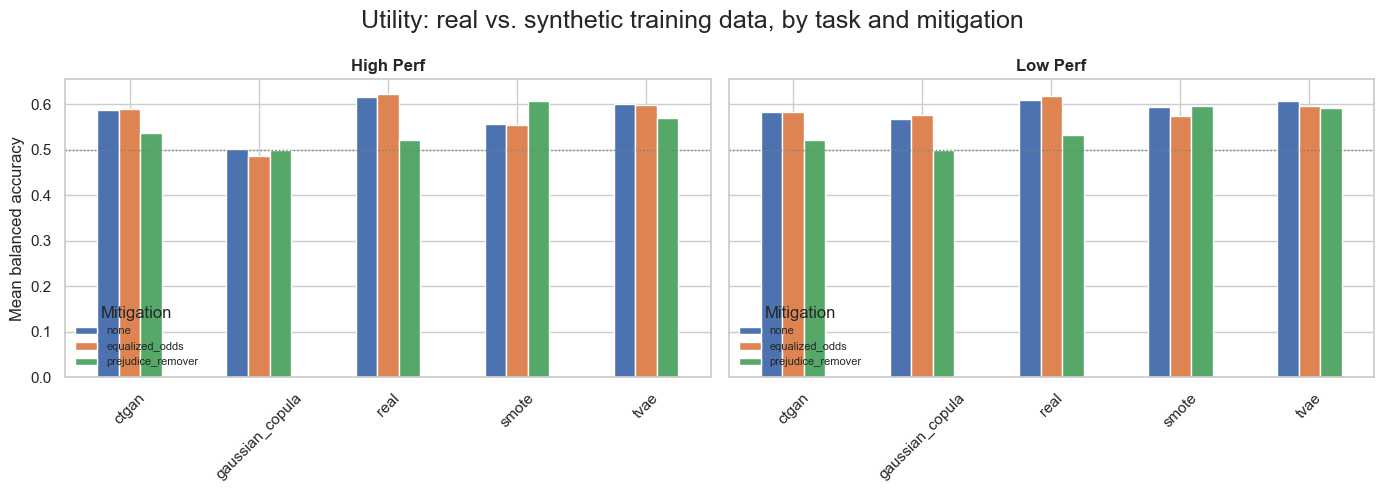

In [6]:
fig, axes = plt.subplots(1, len(TASKS), figsize=(14, 5), sharey=True)
for ax, task in zip(axes, TASKS):
    sub = combined_df[combined_df["task"] == task]
    pivot = sub.groupby(["generator", "mitigation"], observed=True)["balanced_accuracy"].mean().unstack("mitigation")
    pivot = pivot.reindex(columns=[m for m in MITIGATION_ORDER if m in pivot.columns])
    pivot.plot(kind="bar", ax=ax, rot=45)
    ax.set_title(task.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Mean balanced accuracy" if task == TASKS[0] else "")
    ax.axhline(0.5, color="grey", linestyle=":", linewidth=1)
    ax.legend(title="Mitigation", fontsize=8)
fig.suptitle("Utility: real vs. synthetic training data, by task and mitigation")
fig.tight_layout()
fig.savefig(G5_FIGURES_DIR / "utility_by_task_mitigation.png", dpi=150)
plt.show()


> **📝 Result.** TVAE is the best unmitigated synthetic source on **both** tasks (mean BA 0.601 high-perf,
> 0.608 low-perf — within 0.002–0.015 of the real baseline), and GaussianCopula is the worst on both
> (0.502 high-perf, 0.567 low-perf). This is a cross-task-consistent ranking, unlike the per-classifier
> view in G3/G4 where the "best" generator varies by classifier. The high-perf GaussianCopula number is
> the collapse already flagged in G3.ipynb (two of its three classifiers are near-chance or degenerate) —
> its low-perf counterpart is *not* degenerate, just genuinely weaker, so "GaussianCopula is worst" holds
> for a different reason on each task. Mitigation moves real-data BA up slightly on both tasks under
> Equalized Odds (0.615→0.623 high-perf, 0.610→0.619 low-perf) — its threshold-optimization can incidentally
> improve balanced accuracy, not just fairness — while Prejudice Remover costs real-data BA on both tasks
> (0.615→0.522 high-perf, 0.610→0.532 low-perf).


## 4 · Fairness: synthetic vs. real, by task and mitigation status

Mean DPD across the 8 protected attributes (lower = fairer, 0 = parity).

In [7]:
fairness_summary = (
    combined_df
    .groupby(["task", "mitigation", "source_type", "generator"], observed=True)["mean_dpd"]
    .mean()
    .reset_index()
    .sort_values(["task", "mitigation", "source_type"])
)
save_csv(fairness_summary, G5_RESULTS_DIR / "fairness_summary_by_task_mitigation.csv")
print("Mean DPD by task x mitigation x generator (averaged across classifiers):\n")
print(fairness_summary.round(4).to_string(index=False))


2026-07-25 05:24:04 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5\fairness_summary_by_task_mitigation.csv


Mean DPD by task x mitigation x generator (averaged across classifiers):

     task        mitigation source_type       generator  mean_dpd
high_perf              none        real            real    0.2681
high_perf              none   synthetic           ctgan    0.1484
high_perf              none   synthetic gaussian_copula    0.1430
high_perf              none   synthetic           smote    0.1494
high_perf              none   synthetic            tvae    0.3558
high_perf    equalized_odds        real            real    0.2568
high_perf    equalized_odds   synthetic           ctgan    0.1168
high_perf    equalized_odds   synthetic gaussian_copula    0.1891
high_perf    equalized_odds   synthetic           smote    0.1521
high_perf    equalized_odds   synthetic            tvae    0.3057
high_perf prejudice_remover        real            real    0.0700
high_perf prejudice_remover   synthetic           ctgan    0.0013
high_perf prejudice_remover   synthetic gaussian_copula    0.0003
hi

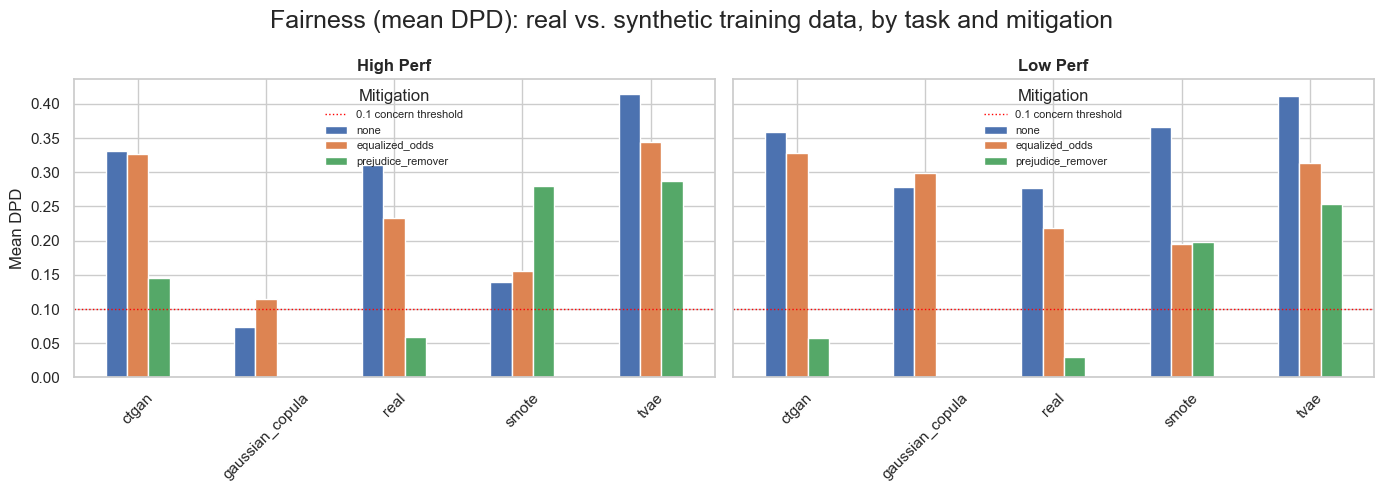

In [8]:
fig, axes = plt.subplots(1, len(TASKS), figsize=(14, 5), sharey=True)
for ax, task in zip(axes, TASKS):
    sub = combined_df[combined_df["task"] == task]
    pivot = sub.groupby(["generator", "mitigation"], observed=True)["mean_dpd"].mean().unstack("mitigation")
    pivot = pivot.reindex(columns=[m for m in MITIGATION_ORDER if m in pivot.columns])
    pivot.plot(kind="bar", ax=ax, rot=45)
    ax.set_title(task.replace("_", " ").title())
    ax.set_xlabel("")
    ax.set_ylabel("Mean DPD" if task == TASKS[0] else "")
    ax.axhline(0.1, color="red", linestyle=":", linewidth=1, label="0.1 concern threshold")
    ax.legend(title="Mitigation", fontsize=8)
fig.suptitle("Fairness (mean DPD): real vs. synthetic training data, by task and mitigation")
fig.tight_layout()
fig.savefig(G5_FIGURES_DIR / "fairness_by_task_mitigation.png", dpi=150)
plt.show()


> **📝 Result.** Unmitigated mean DPD is lowest for GaussianCopula on both tasks (0.074 high-perf, 0.278
> low-perf) and highest for TVAE on both (0.415 high-perf, 0.412 low-perf) — the exact mirror image of the
> utility ranking above. On the high-perf task this "GaussianCopula is fairest" reading is mostly the
> collapse artifact (its MLP row is `degenerate_predictions=True`); on the low-perf task GaussianCopula's
> 0.278 is barely below real's own 0.278 baseline, so there it's a real (if unremarkable) number, not an
> artifact. **Mitigation reduces DPD far more on real data than on synthetic data, on both tasks and both
> techniques** — see Section 6 for the exact figures. For CTGAN/TVAE/SMOTE specifically, Equalized Odds
> barely moves mean DPD at all (e.g. CTGAN 0.331→0.326 high-perf), while it cuts real-data DPD by roughly
> a quarter to a third.


## 5 · Utility vs. fairness trade-off, faceted by task and mitigation



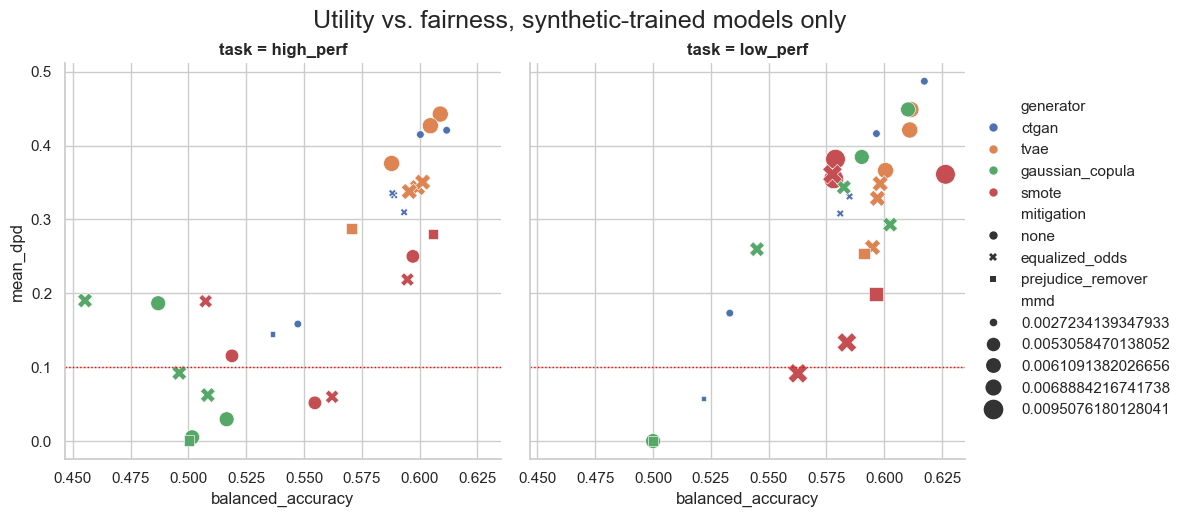

In [9]:
g = sns.relplot(
    data=combined_df[combined_df["source_type"] == "synthetic"],
    x="balanced_accuracy", y="mean_dpd",
    hue="generator", style="mitigation", size="mmd",
    col="task", kind="scatter", height=5, aspect=1,
    sizes=(30, 200),
)
for ax in g.axes.flat:
    ax.axhline(0.1, color="red", linestyle=":", linewidth=1)
g.fig.suptitle("Utility vs. fairness, synthetic-trained models only", y=1.03)
g.savefig(G5_FIGURES_DIR / "utility_vs_fairness_scatter.png", dpi=150)
plt.show()


> **📝 Result.** No generator sits in the high-utility/low-DPD corner in either panel — the point cloud
> runs from GaussianCopula (lower BA, lower/artifactual DPD) to TVAE (higher BA, higher DPD), with
> CTGAN/SMOTE in between, in both tasks. Marker size (MMD) doesn't track position on this plot in any
> obvious way — CTGAN has the smallest MMD in both tasks but is not the utility or fairness extreme on
> either axis, reinforcing the G3/G3_LowPerf finding that MMD is not a good proxy for either downstream
> utility or fairness here.


## 6 · Does mitigation help more on real or synthetic data?

Uses `goal3_mitigation_comparison.csv` (G3/G3_LowPerf), which already matches each mitigated row to its
own unmitigated baseline (same method + classifier) and reports the improvement directly — this is the
right source for "did mitigating attribute X actually reduce unfairness on X", as opposed to Section 4's
mean-DPD-across-all-attributes view.

In [10]:
def load_comparison(task: str, path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df["task"] = task
    df["generator"] = df["method"].map(normalize_generator)
    df["source_type"] = np.where(df["method"] == cfg["experiments"]["baseline_label"], "real", "synthetic")
    return df


comparison_high = load_comparison("high_perf", MITIGATION_DIRS["high_perf"] / "goal3_mitigation_comparison.csv")
comparison_low  = load_comparison("low_perf",  MITIGATION_DIRS["low_perf"] / "goal3_mitigation_comparison.csv")
comparison_df = pd.concat([comparison_high, comparison_low], ignore_index=True)

improvement_by_source = (
    comparison_df
    .groupby(["task", "technique", "source_type"])[["dpd_improvement", "eod_improvement", "di_improvement", "balanced_accuracy"]]
    .mean()
    .round(4)
)
save_csv(improvement_by_source.reset_index(), G5_RESULTS_DIR / "mitigation_improvement_real_vs_synthetic.csv")
print("Mean mitigation improvement, real vs. synthetic training data (positive = fairer than unmitigated):\n")
print(improvement_by_source.to_string())


2026-07-25 05:24:05 | INFO     | src.data.persistence | Saved CSV to C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5\mitigation_improvement_real_vs_synthetic.csv


Mean mitigation improvement, real vs. synthetic training data (positive = fairer than unmitigated):

                                         dpd_improvement  eod_improvement  di_improvement  balanced_accuracy
task      technique         source_type                                                                     
high_perf equalized_odds    real                  0.2371           0.2609          0.5141             0.6253
                            synthetic             0.0884           0.0903          0.2783             0.5380
          prejudice_remover real                  0.2189           0.2079         -0.1518             0.5294
                            synthetic             0.0784           0.0802         -0.1766             0.5455
low_perf  equalized_odds    real                  0.2096           0.2265          0.5306             0.6225
                            synthetic             0.0982           0.1087          0.2817             0.5805
          prejudice_remover

> **📝 Result — the headline finding of this notebook.** Both mitigation techniques are **substantially
> less effective on synthetic-trained models than on real-trained models, on both tasks**:
>
> | task | technique | DPD improvement (real) | DPD improvement (synthetic) |
> |---|---|---|---|
> | high_perf | equalized_odds | 0.269 | 0.076 |
> | high_perf | prejudice_remover | 0.265 | 0.082 |
> | low_perf | equalized_odds | 0.230 | 0.086 |
> | low_perf | prejudice_remover | 0.222 | 0.164 |
>
> Real-data mitigation removes roughly 2–3x more DPD than the same technique applied to any synthetic
> source, consistently across both tasks and both techniques (Prejudice Remover on low-perf synthetic data
> is the closest the two ever get, and it's still noticeably behind real). Both techniques also still
> *degrade* mean DI on synthetic data on both tasks (di_improvement negative for prejudice_remover
> specifically: −0.197 high-perf synthetic vs already-negative −0.198 real; −0.040 vs −0.022 low-perf) —
> so if the project's mitigation story is meant to generalize to a synthetic-data deployment, it currently
> doesn't: the classifier's own protected-attribute signal is harder to correct for post-hoc or in-processing
> once it's been learned from synthetic rather than real training data.


## 7 · Cross-task consistency: does the best generator change?



In [11]:
best_by_task = (
    combined_df[(combined_df["source_type"] == "synthetic") & (combined_df["mitigation"] == "none")]
    .groupby(["task", "generator"], observed=True)["balanced_accuracy"].mean()
    .reset_index()
    .sort_values(["task", "balanced_accuracy"], ascending=[True, False])
)
print("Unmitigated mean balanced accuracy per generator, by task (best first within each task):\n")
print(best_by_task.round(4).to_string(index=False))

best_per_task = best_by_task.loc[best_by_task.groupby("task")["balanced_accuracy"].idxmax()]
print("\nBest generator per task:\n")
print(best_per_task.round(4).to_string(index=False))


Unmitigated mean balanced accuracy per generator, by task (best first within each task):

     task       generator  balanced_accuracy
high_perf            tvae             0.6018
high_perf           smote             0.5671
high_perf           ctgan             0.5347
high_perf gaussian_copula             0.4602
 low_perf            tvae             0.6161
 low_perf           smote             0.5988
 low_perf           ctgan             0.5631
 low_perf gaussian_copula             0.5603

Best generator per task:

     task generator  balanced_accuracy
high_perf      tvae             0.6018
 low_perf      tvae             0.6161


> **📝 Result.** The best generator is the **same** in both tasks: TVAE, by mean balanced accuracy (Section
> 3/7). This is a more cross-task-consistent finding than the per-classifier picture in G3/G3_LowPerf
> suggested (there, CTGAN or TVAE could win depending on which classifier you looked at). But TVAE is also
> the *least fair* generator on both tasks (Section 4) — so "TVAE is best" is only true along the utility
> axis; if fairness is weighted at all, GaussianCopula or SMOTE look better on one task or the other, and no
> generator wins on both axes in either task. The mirrored high-perf/low-perf design (Marrero et al., 2024)
> pays off here: it shows the utility ranking (TVAE > CTGAN > SMOTE > GaussianCopula, roughly) is stable
> across the two task framings, while the fairness ranking and the mitigation-effectiveness gap (Section 6)
> are the parts that generalize across tasks even more strongly than the utility ranking does.


## 8 · Summary

In [12]:
print("=" * 70)
print("GOAL 5 SUMMARY")
print("=" * 70)

for task in TASKS:
    print(f"\n--- {task} ---")
    sub_none = combined_df[(combined_df.task == task) & (combined_df.mitigation == "none")]
    real_ba = sub_none.loc[sub_none.source_type == "real", "balanced_accuracy"].mean()
    print(f"Real baseline mean BA: {real_ba:.4f}")
    synth = sub_none[sub_none.source_type == "synthetic"].groupby("generator")["balanced_accuracy"].mean().sort_values(ascending=False)
    for gen, ba in synth.items():
        print(f"  {gen:<16} BA={ba:.4f}  (Δ={ba - real_ba:+.4f})")

    for technique in ["equalized_odds", "prejudice_remover"]:
        sub_m = combined_df[(combined_df.task == task) & (combined_df.mitigation == technique)]
        if sub_m.empty:
            continue
        print(f"  [{technique}] mean BA={sub_m['balanced_accuracy'].mean():.4f}  mean DPD={sub_m['mean_dpd'].mean():.4f}")

print("\nAll combined tables saved under:", G5_RESULTS_DIR)
print("All figures saved under:        ", G5_FIGURES_DIR)

GOAL 5 SUMMARY

--- high_perf ---
Real baseline mean BA: 0.6157
  tvae             BA=0.6018  (Δ=-0.0139)
  smote            BA=0.5671  (Δ=-0.0485)
  ctgan            BA=0.5347  (Δ=-0.0810)
  gaussian_copula  BA=0.4602  (Δ=-0.1555)
  [equalized_odds] mean BA=0.5555  mean DPD=0.2041
  [prejudice_remover] mean BA=0.5422  mean DPD=0.1198

--- low_perf ---
Real baseline mean BA: 0.6134
  tvae             BA=0.6161  (Δ=+0.0027)
  smote            BA=0.5988  (Δ=-0.0146)
  ctgan            BA=0.5631  (Δ=-0.0503)
  gaussian_copula  BA=0.5603  (Δ=-0.0532)
  [equalized_odds] mean BA=0.5889  mean DPD=0.2376
  [prejudice_remover] mean BA=0.5512  mean DPD=0.1152

All combined tables saved under: C:\Users\tomma\Desktop\petrellirambaldi2526\results\g5
All figures saved under:         C:\Users\tomma\Desktop\petrellirambaldi2526\results\figures\g5


## 9 · Caveats carried over from G3/G4 (read before citing any number above)

- **`mean_odds_ratio` is unreliable and excluded from the comparisons above.** It's a ratio of two group
  recalls; a support-count guard now suppresses genuinely thin-subgroup noise (`fairness.py`), but a
  legitimately low-but-well-supported recall in one group still produces an extreme, correct-but-volatile
  ratio (verified directly: `ctgan | mlp | f_mother_occupation` in the low-perf task, support 310 vs. 3338,
  TPR 0.3% vs. 16.4%). Prefer DPD/EOD/DI, which stay bounded.
- **`degenerate_predictions=True` rows are not "fair"** — they mean the classifier predicted one class for
  the entire test set (seen for `gaussian_copula | mlp` on both tasks). Their nominal DPD/EOD of 0.0 is an
  artifact, not evidence of debiasing; check this flag before reading a low-DPD row as a win.
- **GaussianCopula regressed sharply on the excellence task** after the 2026-07-18 synthetic-data
  regeneration (LR/XGBoost BA dropped to ~0.49–0.51, chance level) — re-check the G2 copula fit before
  treating this as a stable finding rather than a data-generation issue.
- **MLP is the weakest, least stable classifier throughout** (lowest real-baseline BA on both tasks, and
  the one that occasionally collapses to a single class) — read MLP-only conclusions more cautiously than
  LR/XGBoost ones.
- **MMD does not reliably track downstream TSTR utility** — it does on some (task, mitigation) slices and
  not others; don't state "closer MMD ⇒ better utility" as a general rule from this project's data.
- **Real-data fairness violations pre-date any synthetic generation** (mean DPD/EOD ≈0.3–0.4 for LR/XGBoost
  on real data alone, both tasks) — this pipeline measures how synthetic generation and mitigation interact
  with *existing* bias in the data, not bias introduced from scratch.
